In [43]:
import pandas as pd
import numpy as np
import duckdb
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingRegressor
import xgboost as xgb
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import VotingClassifier
import lightgbm as lgb



df_train=pd.read_csv('/content/drive/MyDrive/Kaggle/titanic/train.csv')

df_test=pd.read_csv('/content/drive/MyDrive/Kaggle/titanic/test.csv')


In [44]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [45]:
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [46]:
# Объединим датасеты в один (df_all)
# Добавляем метку-идентификатор происхождения
df_train['source'] = 'train'
df_test['source'] = 'test'

# Объединяем вертикально (друг под другом)
df_all = pd.concat([df_train, df_test], ignore_index=True, sort=False)

print(f"Размер объединённого датасета: {df_all.shape}")
print(f"Из них train: {df_all[df_all['source'] == 'train'].shape[0]}")
print(f"Из них test: {df_all[df_all['source'] == 'test'].shape[0]}")

Размер объединённого датасета: (1309, 13)
Из них train: 891
Из них test: 418


In [47]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
 12  source       1309 non-null   object 
dtypes: float64(3), int64(4), object(6)
memory usage: 133.1+ KB


Проанализируем столбцы с числовыми значениями на наличие выбросов.

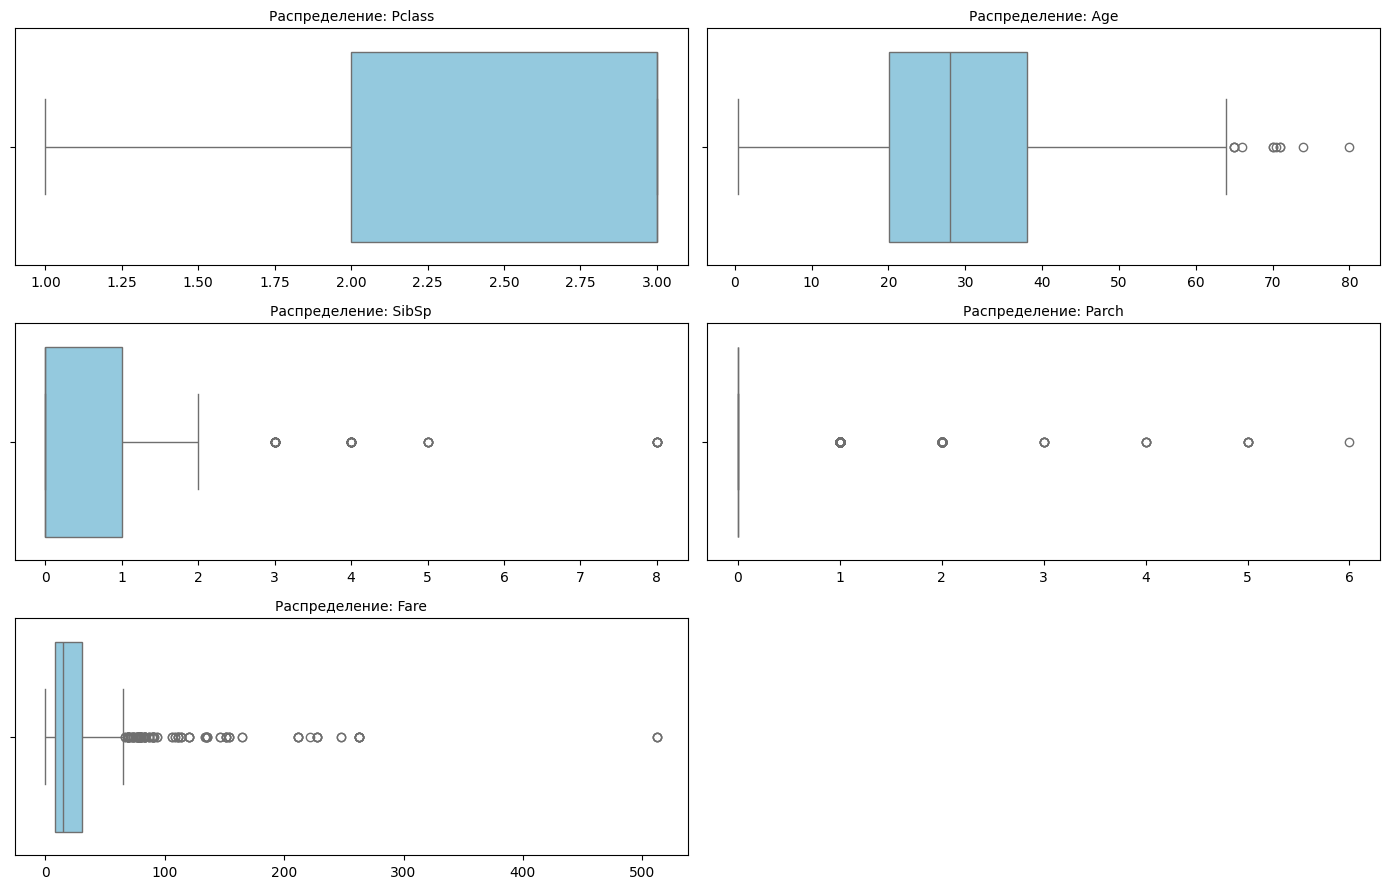

In [48]:
# Выбираем числовые столбцы
numeric_cols = df_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
# Исключаем PassengerId (идентификатор) и Survived (целевая переменная)
numeric_cols = [col for col in numeric_cols if col not in ['PassengerId', 'Survived']]

# Рассчитываем количество строк и столбцов
n_cols = 2  # два графика в строке
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

# Создаём сетку
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3 * n_rows))
axes = axes.flatten()  # упрощаем доступ к осям

# Строим графики
for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df_train[col], orient='h', ax=axes[i], color='skyblue')
    axes[i].set_title(f'Распределение: {col}', fontsize=10)
    axes[i].set_xlabel('')

# Скрываем лишние оси (если графиков меньше, чем мест)
for i in range(len(numeric_cols), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

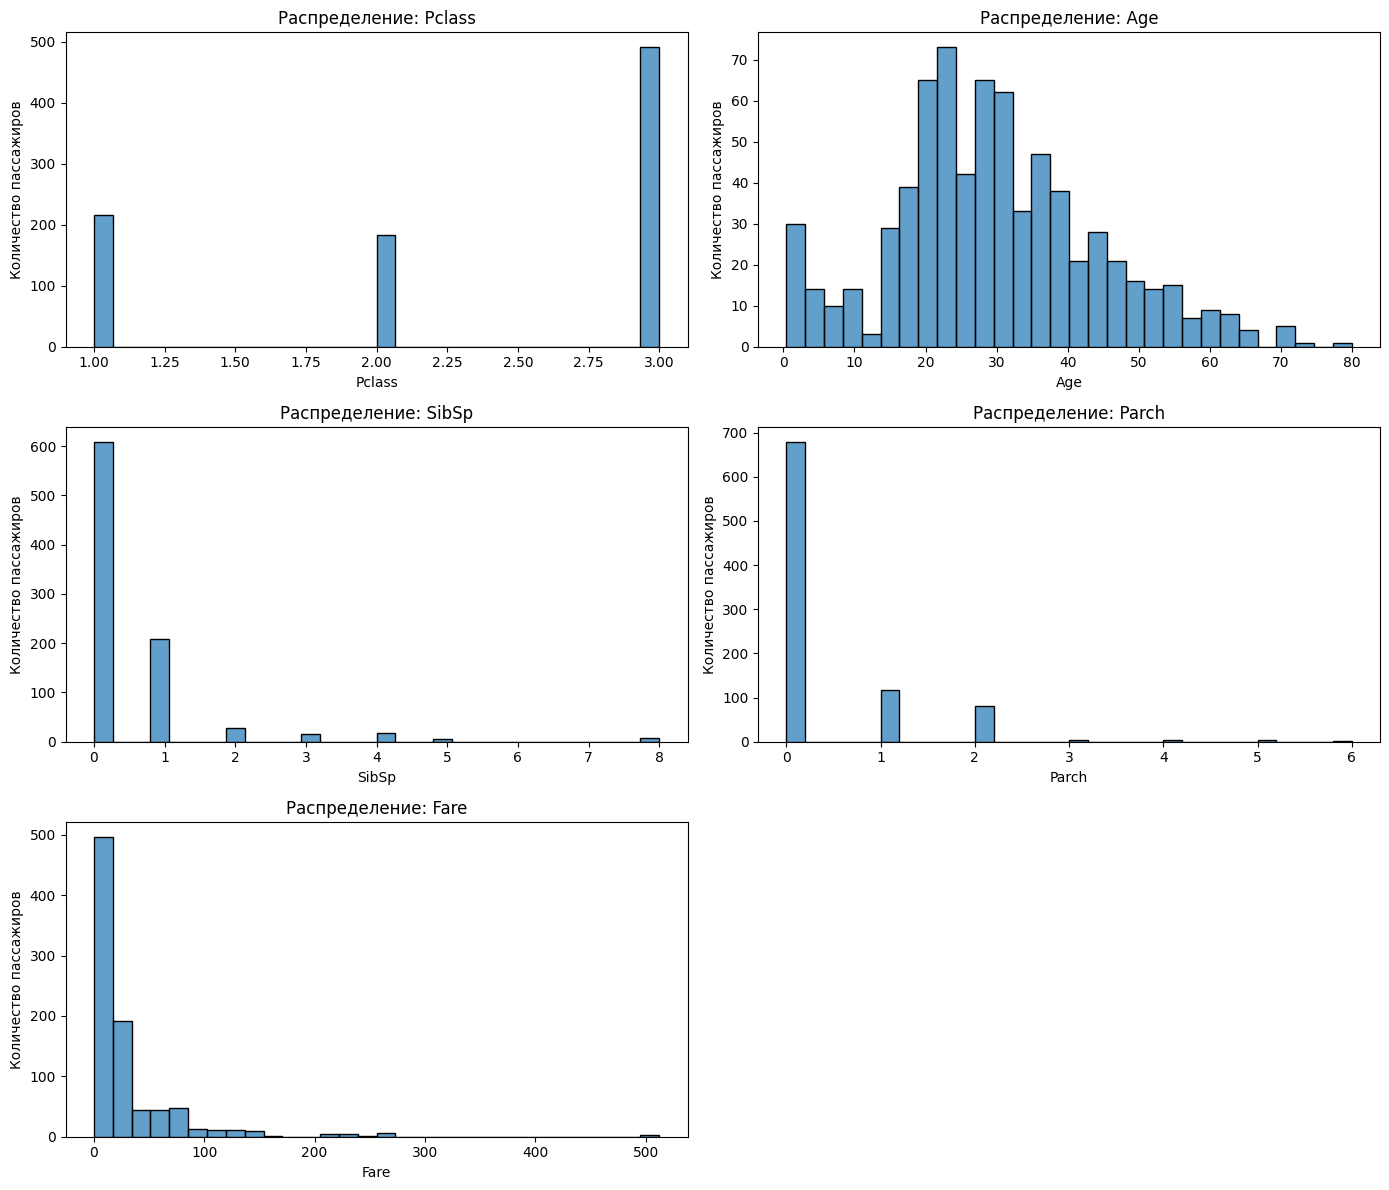

In [49]:
# Выбираем числовые столбцы (исключаем PassengerId и Survived)
numeric_cols = df_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols = [col for col in numeric_cols if col not in ['PassengerId', 'Survived']]

# Настраиваем сетку
n_cols = 2
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

# Создаём фигуру и оси
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

# Строим графики
for i, col in enumerate(numeric_cols):
    sns.histplot(data=df_train, x=col, ax=axes[i], bins=30, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Распределение: {col}', fontsize=12)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Количество пассажиров', fontsize=10)

# Скрываем лишние оси
for i in range(len(numeric_cols), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

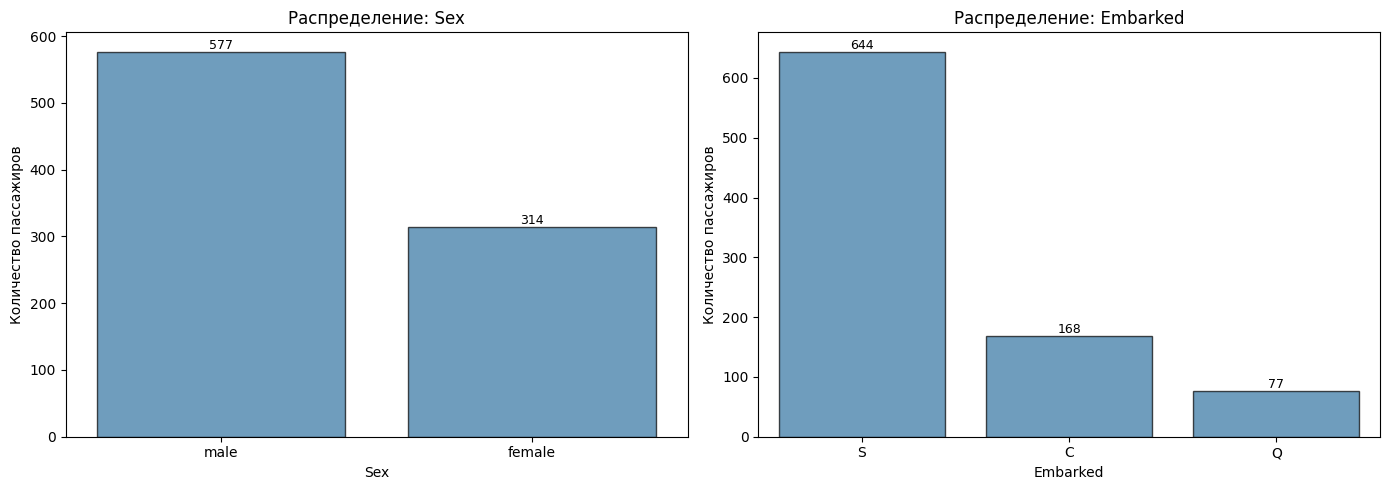

In [50]:
# Выбираем категориальные (нечисловые) столбцы
categorical_cols = df_train.select_dtypes(include=['object']).columns.tolist()
# Исключаем ненужные (например, Name и Ticket могут иметь много уникальных значений)
categorical_cols = [col for col in categorical_cols if col not in ['Name', 'Ticket', 'PassengerId', 'Cabin', 'source']]

# Настраиваем сетку
n_cols = 2
n_rows = (len(categorical_cols) + n_cols - 1) // n_cols

# Создаём фигуру и оси
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten()

# Строим графики
for i, col in enumerate(categorical_cols):
    # Сортируем по убыванию для лучшей читаемости
    order = df_train[col].value_counts().index

    sns.countplot(data=df_train, x=col, ax=axes[i], order=order,
                  edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Распределение: {col}', fontsize=12)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Количество пассажиров', fontsize=10)
    axes[i].tick_params(axis='x', rotation=0)

    # Добавляем значения на столбцы
    for p in axes[i].patches:
        axes[i].annotate(f'{int(p.get_height())}',
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom', fontsize=9)

# Скрываем лишние оси
for i in range(len(categorical_cols), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [51]:
# Определим пассажира с пропущенной стоимостью билета
df_all[df_all['Fare'].isna()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,source
1043,1044,NaN,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,NaN,S,test


In [52]:
# Определим среднее значение для заполнения пустого поля
df_all_fare_none = duckdb.sql("""
    SELECT
        avg(Fare) as avg_Fare
    FROM df_all
    where Pclass=3 and Sex='male' and Embarked='S'
""").df()

print(df_all_fare_none)

    avg_Fare
0  13.145977


In [53]:
# Заполняем пустое значение полученным средним
df_all.loc[df_all['PassengerId'] == 1044, 'Fare'] = 13.1

In [54]:
# Логарифмическая трансформация (np.log1p = log(1+x), безопасно для нулей)
# Создаем новый признак Fare_log, от Fare отказываемся из-за слишком большого смещения.
df_all['Fare_log'] = np.log1p(df_all['Fare'])

Пассажиры с PassengerId 62 и 830 это Марта Эвелин Стоун с её горничной - Амели Икард. Их порт посадки согласно историческим данным Саутгемптон (S).

In [55]:
# Заполняем пустое значение для пассажиров с PassengerId 62 и 830
df_all.loc[df_all['PassengerId'].isin([62, 830]), 'Embarked'] = 'S'

In [56]:
# Создадим новые столбцы
df_all = duckdb.sql("""
    SELECT
        PassengerId,
        Survived,
        Pclass,
        Name,
        Sex,
        Age,
        SibSp,
        Parch,
        Ticket,
        Fare,
        if(Cabin is Null, 'Unknown', Cabin) as Cabin,
        Embarked,
        source,
        Fare_log,
        regexp_extract(Name, ' ([A-Za-z]+)\.', 1) as Title,
        if(Cabin is Null, 'Unknown', substring(Cabin, 1, 1)) AS Cabin_abr,
        if(Pclass=3 and Sex='male', 1, 0) as High_risk,
        if(regexp_matches(split_part(Ticket, ' ', 1), '^[0-9]+$'), '',
           split_part(Ticket, ' ', 1)) AS Ticket_abr,
        if(Cabin is Null, 0, 1) as Cabin_known,
        SibSp+Parch+1 as FamilySize
    FROM df_all

""").df()

print(df_all)

      PassengerId  Survived  Pclass  \
0               1       0.0       3   
1               2       1.0       1   
2               3       1.0       3   
3               4       1.0       1   
4               5       0.0       3   
...           ...       ...     ...   
1304         1305       NaN       3   
1305         1306       NaN       1   
1306         1307       NaN       3   
1307         1308       NaN       3   
1308         1309       NaN       3   

                                                   Name     Sex   Age  SibSp  \
0                               Braund, Mr. Owen Harris    male  22.0      1   
1     Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                                Heikkinen, Miss. Laina  female  26.0      0   
3          Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                              Allen, Mr. William Henry    male  35.0      0   
...                                                

<>:18: SyntaxWarning: invalid escape sequence '\.'
<>:18: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_4634/2384271902.py:18: SyntaxWarning: invalid escape sequence '\.'
  regexp_extract(Name, ' ([A-Za-z]+)\.', 1) as Title,


In [57]:
# Кодируем категориальные признаки в числа: Name, Sex, Ticket, Cabin, Embarked, Title, Cabin_abr, Ticket_abr

le_Name = LabelEncoder()
le_Sex = LabelEncoder()
le_Ticket = LabelEncoder()
le_Cabin = LabelEncoder()
le_Embarked = LabelEncoder()
le_Title = LabelEncoder()
le_Cabin_abr = LabelEncoder()
le_Ticket_abr = LabelEncoder()

df_all['Name_Code'] = le_Name.fit_transform(df_all['Name'])
df_all['Sex_Code'] = le_Sex.fit_transform(df_all['Sex'])
df_all['Ticket_Code'] = le_Ticket.fit_transform(df_all['Ticket'])
df_all['Cabin_Code'] = le_Cabin.fit_transform(df_all['Cabin'])
df_all['Embarked_Code'] = le_Embarked.fit_transform(df_all['Embarked'])
df_all['Title_Code'] = le_Title.fit_transform(df_all['Title'])
df_all['Cabin_abr_Code'] = le_Cabin_abr.fit_transform(df_all['Cabin_abr'])
df_all['Ticket_abr_Code'] = le_Ticket_abr.fit_transform(df_all['Ticket_abr'])

# Оставляем только строки с известным возрастом
df_all_age_known = df_all[df_all['Age'].notna()].copy()

# Определяем признаки для обучения модели для предсказания возраста
features_for_age_prediction = ['Pclass', 'SibSp', 'Parch', 'Fare_log',
                'High_risk', 'Cabin_known', 'FamilySize', 'Sex_Code', 'Cabin_Code', 'Embarked_Code', 'Title_Code', 'Cabin_abr_Code', 'Ticket_abr_Code']
# X_unknown — строки с пропущенным возрастом (только признаки)
X_unknown = df_all[df_all['Age'].isna()][features_for_age_prediction]


# Выбор числовых признаков для корреляции

# Выбираем только числовые колонки для оценки корреляции
numeric_cols_for_correlation = ['Age', 'Pclass', 'SibSp', 'Parch', 'Fare_log',
                'High_risk', 'Cabin_known', 'FamilySize', 'Sex_Code', 'Cabin_Code', 'Embarked_Code', 'Title_Code', 'Cabin_abr_Code', 'Ticket_abr_Code']

corr_matrix = df_all_age_known[numeric_cols_for_correlation].corr()

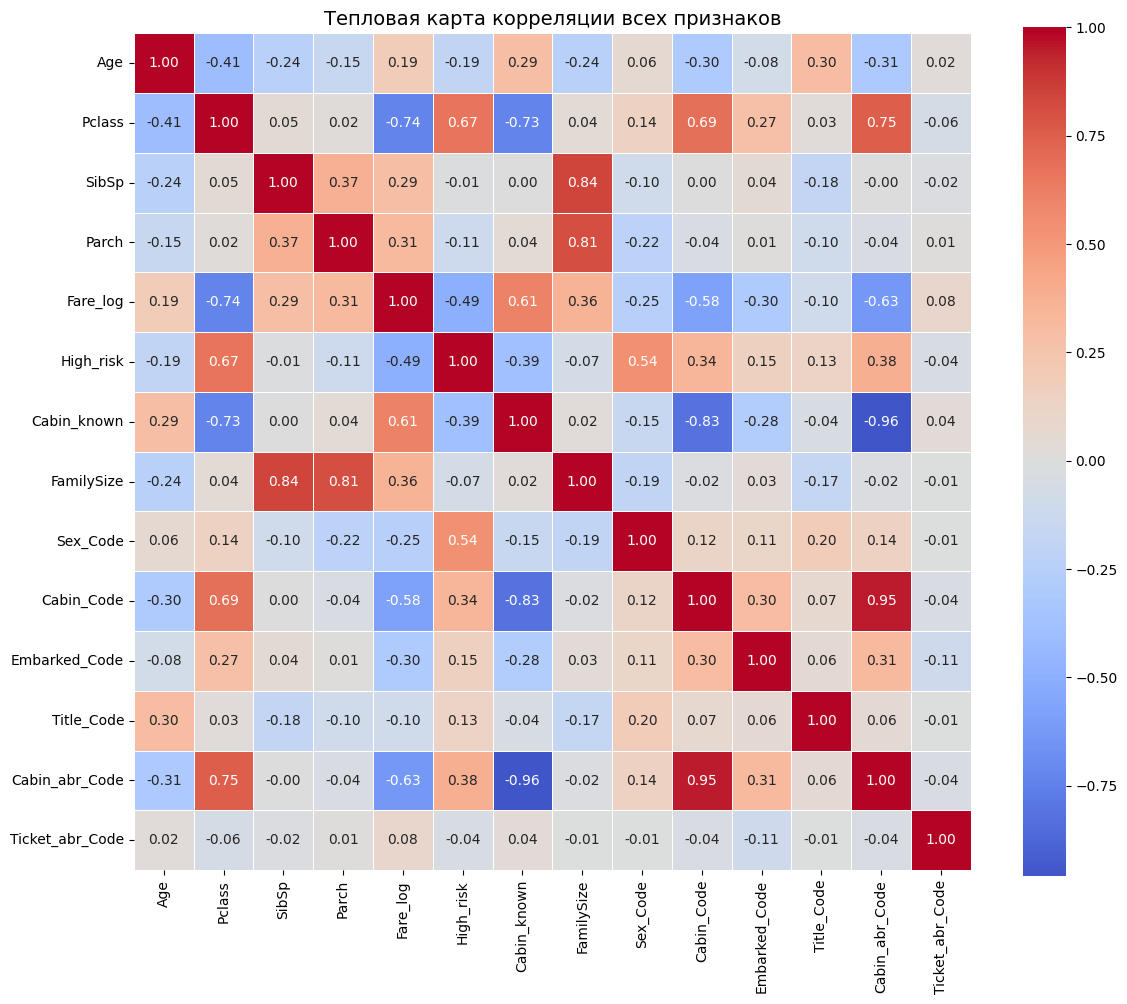

In [58]:
# Тепловая карта корреляций (полная)

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix,
            annot=True,      # показывать числа
            cmap='coolwarm', # красный = положительная, синий = отрицательная
            center=0,
            fmt='.2f',
            square=True,
            linewidths=0.5)
plt.title('Тепловая карта корреляции всех признаков', fontsize=14)
plt.tight_layout()
plt.show()

In [60]:
# Обучаем модель для определения возраста

# Подготовка данных
X = df_all_age_known[['Pclass', 'SibSp', 'Parch', 'Fare_log',
                'High_risk', 'Cabin_known', 'FamilySize', 'Sex_Code', 'Cabin_Code', 'Embarked_Code', 'Title_Code', 'Cabin_abr_Code', 'Ticket_abr_Code']]
y = df_all_age_known['Age']

# Создаём модель
model = LinearRegression()

# Кросс-валидация
scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_absolute_error')

# Вывод результата
print(f"Результаты по 5 складкам: {scores}")
print(f"Средняя MAE: {-scores.mean():.2f} лет")
print(f"Разброс (стандартное отклонение): {scores.std():.3f}")

# Более наглядный вывод
print(f"Модель ошибается в среднем на {-scores.mean():.1f} ± {scores.std():.1f} лет")

Результаты по 5 складкам: [ -9.11093067  -9.67165414 -10.31016459  -9.24863073  -9.61618114]
Средняя MAE: 9.59 лет
Разброс (стандартное отклонение): 0.418
Модель ошибается в среднем на 9.6 ± 0.4 лет


In [61]:
# Попробуем более мощную модель

# RandomForest часто даёт лучше результат на табличных данных
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
scores_rf = cross_val_score(model_rf, X, y, cv=5, scoring='neg_mean_absolute_error')
print(f"RandomForest MAE: {-scores_rf.mean():.2f} (+/- {scores_rf.std():.2f})")

RandomForest MAE: 8.55 (+/- 0.39)


In [62]:
#Попробуем градиентный бустинг

gbr = GradientBoostingRegressor(random_state=42)
scores_gbr = cross_val_score(gbr, X, y, cv=5, scoring='neg_mean_absolute_error')
print(f"GradientBoosting MAE: {-scores_gbr.mean():.2f} (+/- {scores_gbr.std():.2f})")

GradientBoosting MAE: 8.26 (+/- 0.33)


In [63]:
# Обучаем финальную модель на ВСЕХ известных данных
final_model = GradientBoostingRegressor(random_state=42)    # Создаёт "пустой" экземпляр модели градиентного бустинга для регрессии.
final_model.fit(X, y)  # X — все строки с известным возрастом

# Предсказываем пропуски (заполняем пропуски рассчитанными данными)
predicted_ages = final_model.predict(X_unknown)
df_all.loc[df_all['Age'].isna(), 'Age'] = predicted_ages

Заполнили все пропуски и обработали выбросы.

In [64]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 28 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PassengerId      1309 non-null   int64  
 1   Survived         891 non-null    float64
 2   Pclass           1309 non-null   int64  
 3   Name             1309 non-null   object 
 4   Sex              1309 non-null   object 
 5   Age              1309 non-null   float64
 6   SibSp            1309 non-null   int64  
 7   Parch            1309 non-null   int64  
 8   Ticket           1309 non-null   object 
 9   Fare             1309 non-null   float64
 10  Cabin            1309 non-null   object 
 11  Embarked         1309 non-null   object 
 12  source           1309 non-null   object 
 13  Fare_log         1309 non-null   float64
 14  Title            1309 non-null   object 
 15  Cabin_abr        1309 non-null   object 
 16  High_risk        1309 non-null   int32  
 17  Ticket_abr    

Разделяем обратно на train и test

In [65]:
# Разделяем
df_train = df_all[df_all['source'] == 'train'].copy()
df_test = df_all[df_all['source'] == 'test'].copy()

# Удаляем вспомогательные колонки
df_train = df_train.drop('source', axis=1)
df_test = df_test.drop('source', axis=1)

# Удаляем из test колонку Survived (если она есть, но с NaN)
if 'Survived' in df_test.columns:
    df_test = df_test.drop('Survived', axis=1)

In [66]:
# Подготовка данных для модели
# Определяем целевые признаки (целевая переменная - Survived)
target = 'Survived'

# Определяем финальные признаки для модели
features = ['Pclass', 'SibSp', 'Parch', 'Fare_log',
            'High_risk', 'Cabin_known', 'FamilySize', 'Sex_Code', 'Cabin_Code',
            'Embarked_Code', 'Title_Code', 'Cabin_abr_Code', 'Ticket_abr_Code']

# Убеждаемся, что все признаки есть в train и test
X_train = df_train[features]
y_train = df_train[target]

X_test = df_test[features]

# Проверяем, что нет пропусков
print(f"Пропуски в X_train: {X_train.isnull().sum().sum()}")
print(f"Пропуски в X_test: {X_test.isnull().sum().sum()}")

Пропуски в X_train: 0
Пропуски в X_test: 0


In [70]:
# Обучение модели
#model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42) дала результат 0.77751
#model = lgb.LGBMClassifier(n_estimators=200, max_depth=4,
#                           learning_rate=0.05, random_state=42, verbose=-1)     дала результат 0.77272
model = lgb.LGBMClassifier(
    n_estimators=300,           # Больше деревьев
    max_depth=5,                # Чуть глубже (но не слишком, чтобы не переобучить)
    learning_rate=0.03,         # Меньший шаг, но больше деревьев
    subsample=0.8,              # Сэмплирование строк
    colsample_bytree=0.8,       # Сэмплирование колонок
    reg_alpha=0.05,             # Немного L1 регуляризации
    reg_lambda=0.05,            # Немного L2 регуляризации
    random_state=42,
    verbose=-1)




# Кросс-валидация
scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
print(f"CV accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})")

# Обучаем на всех тренировочных данных
model.fit(X_train, y_train)

# --- Предсказания ---
# Вариант 1: Получаем вероятности (если нужны для калибровки или анализа)
y_pred_proba = model.predict_proba(X_test)[:, 1]
print(f"\nПример вероятностей (первые 5): {y_pred_proba[:5]}")

# Вариант 2: Преобразуем в бинарные предсказания (0 или 1)
threshold = 0.5
y_pred_binary = (y_pred_proba >= threshold).astype(int)
print(f"Пример бинарных предсказаний (первые 5): {y_pred_binary[:5]}")

# --- Создание сабмита ---
submission = pd.DataFrame({
    'PassengerId': df_test['PassengerId'],
    'Survived': y_pred_binary
})

# Проверяем, что у нас только 0 и 1
print(f"\nУникальные значения в Survived: {submission['Survived'].unique()}")
print(f"Количество строк: {len(submission)}")

# Сохраняем
submission.to_csv('submission.csv', index=False)
print("\nФайл submission.csv создан!")

CV accuracy: 0.8339 (+/- 0.0240)

Пример вероятностей (первые 5): [0.10475709 0.27964126 0.09502307 0.08547343 0.56654134]
Пример бинарных предсказаний (первые 5): [0 0 0 0 1]

Уникальные значения в Survived: [0 1]
Количество строк: 418

Файл submission.csv создан!
